# 1. Market overview

The frozen research window, the instrument universe, and the anchor check that every run has to pass before anything else happens.

> **Data provenance.** This notebook runs on whichever source the pipeline was given. When the
> source is `SYNTHETIC`, every number below is a property of the simulator in `src/synthetic.py`
> and **not** market history. The only observed market values in the project are the three
> anchors in `config.ANCHORS`. Run `python run_pipeline.py --source fred` on a machine with
> network access to reproduce the identical analysis from live data.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src import backtest, config, features, pipeline, regressions, relative_value, signals

# src.charts selects the Agg backend so the pipeline runs headless; switch back to the
# inline backend afterwards so figures render in the notebook.
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

results = pipeline.run(write_outputs=False)
provenance = results["dataset"].provenance()
print(f"source        {provenance['source']}")
print(f"window        {provenance['start_date']} to {provenance['end_date']}")
print(f"observations  {provenance['daily_observations']:,} trading days")
print(f"validation    {results['validation_log'].summary()}")


source        SYNTHETIC
window        2016-08-15 to 2026-08-13
observations  2,512 trading days
validation    PASS=54


## The anchor check

The project is anchored to three observed market values on 2026-08-13. If the loaded data does not reproduce them, the pipeline aborts rather than producing plausible nonsense. This is the cheapest possible guard against silently loading the wrong series or the wrong window.

In [2]:
panel = results["panel"]
row = panel.loc[config.ANCHOR_DATE]
for name, expected in config.ANCHORS.items():
    print(f"{name:6s} actual {float(row[name]):>10,.2f}   expected {expected:>10,.2f}")
curve_bp = (row["dgs10"] - row["dgs2"]) * config.BP_PER_PCT
print(f"\n2s10s = {row['dgs10']:.2f}% - {row['dgs2']:.2f}% = {curve_bp:+.0f}bp "
      f"(expected {config.ANCHOR_CURVE_2S10S_BP:+.0f}bp)")

spx    actual   7,798.99   expected   7,798.99
dgs2   actual       4.15   expected       4.15
dgs10  actual       4.63   expected       4.63

2s10s = 4.63% - 4.15% = +48bp (expected +48bp)


## Universe and latest levels

Every series carries its own last observation date, so a stale input cannot be compared against a fresh one without it being visible.

In [3]:
from src import reporting

snapshot = reporting.market_snapshot(panel, results["curves"])
snapshot[["series", "label", "asset_class", "fred_id", "latest", "last_observation", "observations", "missing"]]

,series,label,asset_class,fred_id,latest,last_observation,observations,missing
0,dgs2,2y Treasury yield,rates,DGS2,4.1500,2026-08-13,2512,0
1,dgs10,10y Treasury yield,rates,DGS10,4.6300,2026-08-13,2512,0
2,dgs30,30y Treasury yield,rates,DGS30,5.2500,2026-08-13,2512,0
3,real10,10y TIPS real yield,rates,DFII10,2.2000,2026-08-13,2512,0
4,breakeven10,10y breakeven inflation,rates,T10YIE,2.4300,2026-08-13,2512,0
5,fedfunds,Effective fed funds rate,rates,DFF,3.5000,2026-08-13,2512,0
6,usd,Nominal broad USD index (Jan-2006=100),fx,DTWEXBGS,116.5000,2026-08-13,2512,0
7,spx,S&P 500 close,equity,SP500,"7,798.9900",2026-08-13,2512,0
8,ndx,Nasdaq 100 close,equity,NASDAQ100,"28,450.0000",2026-08-13,2512,0
9,vix,Cboe VIX close,volatility,VIXCLS,16.4000,2026-08-13,2512,0


## Cross-asset changes over standard horizons

In [4]:
changes = reporting.cross_asset_changes(panel, results["curves"])
changes[["series", "label", "unit", "latest", "1d", "1w", "1m", "3m", "12m"]]

,series,label,unit,latest,1d,1w,1m,3m,12m
0,dgs2,2y Treasury yield,bp,4.1500,3.1358,24.3798,32.3888,13.8118,45.9730
1,dgs10,10y Treasury yield,bp,4.6300,-2.9558,-2.8948,34.2034,11.2102,44.7014
2,dgs30,30y Treasury yield,bp,5.2500,-7.0387,-14.0092,33.1193,20.2478,71.5647
3,real10,10y TIPS real yield,bp,2.2000,10.0389,30.1229,61.4188,36.0379,66.2507
4,breakeven10,10y breakeven inflation,bp,2.4300,-12.9947,-33.0177,-27.2154,-24.8276,-21.5494
5,fedfunds,Effective fed funds rate,bp,3.5000,0.0000,0.0000,0.0000,-25.0000,-50.0000
6,usd,Nominal broad USD index (Jan-2006=100),%,116.5000,1.1229,2.2301,3.8616,2.6397,-0.1921
7,spx,S&P 500 close,%,"7,798.9900",-1.9906,-8.7376,-13.5164,-10.6873,8.3857
8,ndx,Nasdaq 100 close,%,"28,450.0000",-2.4258,-11.4680,-19.5977,-16.9985,2.8444
9,vix,Cboe VIX close,%,16.4000,-1.3298,10.1491,92.9412,92.9412,92.9412


## The cycle in one picture

Policy, the curve, and the inversion episode.

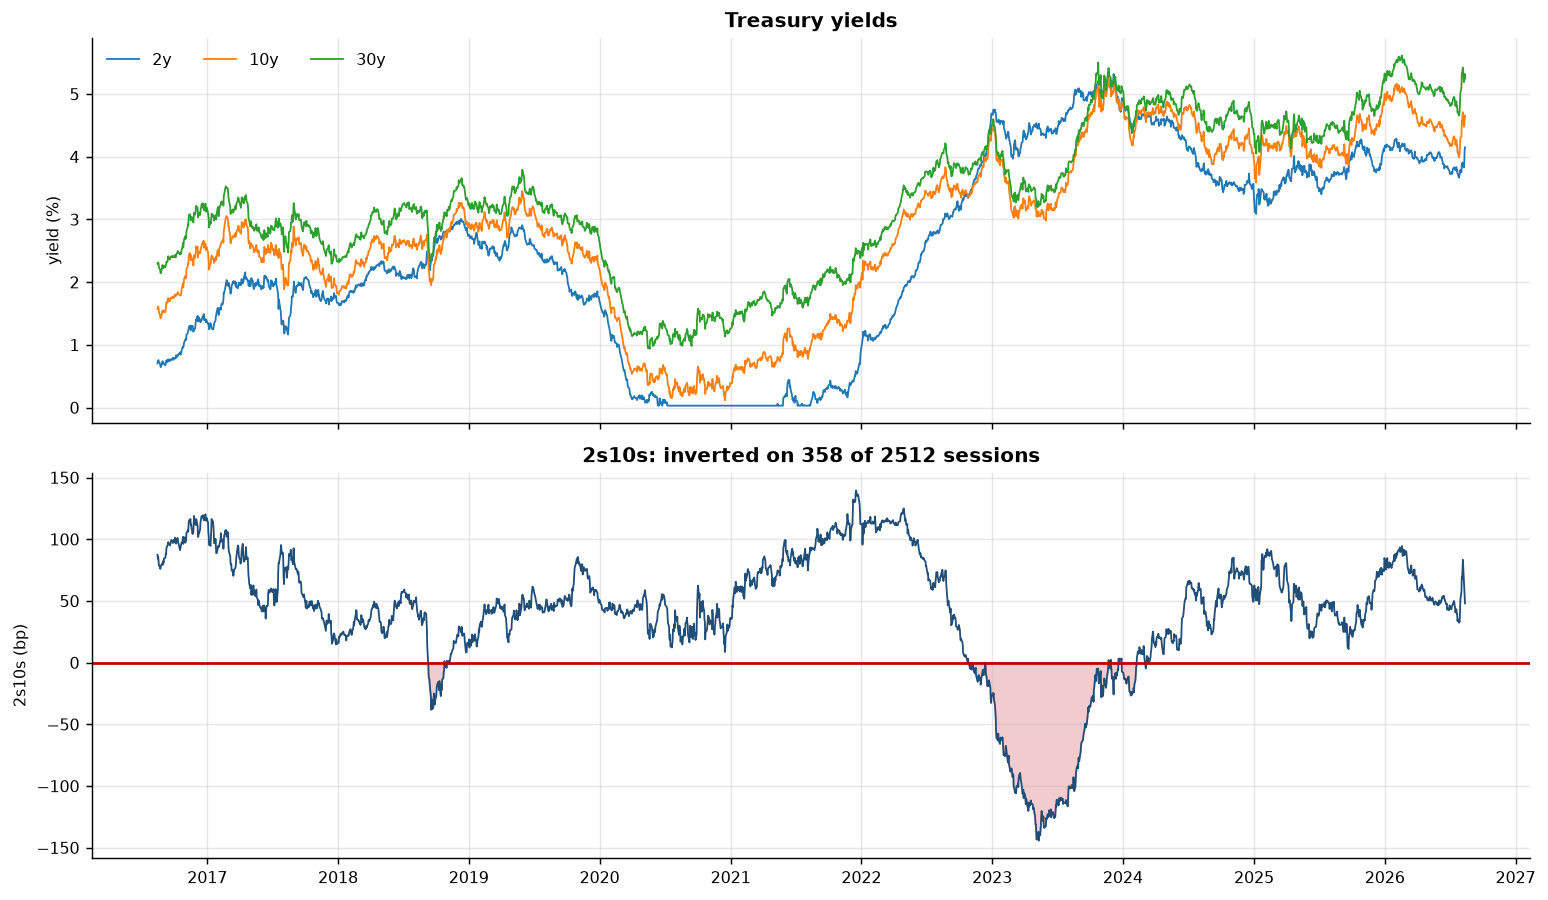

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for column, label in (("dgs2", "2y"), ("dgs10", "10y"), ("dgs30", "30y")):
    axes[0].plot(panel.index, panel[column], linewidth=1.0, label=label)
axes[0].set_ylabel("yield (%)"); axes[0].legend(ncol=3); axes[0].grid(alpha=0.3)
axes[0].set_title("Treasury yields")

curve = results["curves"]["curve_2s10s"]
axes[1].plot(curve.index, curve, linewidth=1.0, color="#1f4e79")
axes[1].axhline(0, color="#c00000")
axes[1].fill_between(curve.index, curve, 0, where=curve < 0, color="#c00000", alpha=0.2)
axes[1].set_ylabel("2s10s (bp)"); axes[1].grid(alpha=0.3)
axes[1].set_title(f"2s10s: inverted on {int((curve < 0).sum())} of {len(curve)} sessions")
plt.tight_layout(); plt.show()

## Regime classification

Four dimensions with fixed rules, so "market conditions" is a label with a day count rather than an adjective. These are ex-post attribution buckets, not tradable filters: the volatility and real-yield breakpoints use full-sample quantiles.

In [6]:
results["regime_summary"]

,dimension,regime,days,share
0,volatility,low VIX (<11.4),838,0.3336
1,volatility,mid VIX (11.4-18.2),837,0.3332
2,volatility,high VIX (>18.2),837,0.3332
3,curve,0-100bp,1921,0.7647
4,curve,inverted,358,0.1425
5,curve,>100bp,233,0.0928
6,real_yield,middle 50% (-0.03-1.48%),1256,0.5000
7,real_yield,bottom quartile (<-0.03%),628,0.2500
8,real_yield,top quartile (>1.48%),628,0.2500
9,usd,USD weakening,1316,0.5374


## Validation

Every check that ran on this execution. Critical failures abort the pipeline; advisory rows document known data limitations instead of hiding them.

In [7]:
log = results["validation"]
print(log["result"].value_counts().to_string())
log[log["check"].str.startswith(("daily", "anchors", "cot", "macro", "futures"))]

result
PASS    54


,check,result,severity,detail
0,daily.no_duplicate_timestamps,PASS,critical,0 duplicated dates in 2512 rows
1,daily.monotonic_index,PASS,critical,index sorted ascending
2,daily.no_future_dates,PASS,critical,max date 2026-08-13 vs frozen end 2026-08-13
3,daily.window_matches_frozen_period,PASS,critical,"2016-08-15 to 2026-08-13, 2512 observations"
4,daily.calendar_alignment,PASS,advisory,"0 expected trading days absent, 0 dates outsid..."
5,daily.positive_prices,PASS,critical,all 6 price series strictly positive (WTI prin...
6,daily.missing_data_documented,PASS,advisory,no missing observations
7,daily.curve_identity,PASS,advisory,2s10s spans -144bp to 140bp; inverted on 358 o...
8,anchors.spx,PASS,critical,"7,798.9900 vs expected 7,798.9900 (tolerance 0..."
9,anchors.dgs2,PASS,critical,4.1500 vs expected 4.1500 (tolerance 0.005) [s...
